In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.classical import expr


def get_dynamic_CNOT_circuit(num_qubit):
    """
    (1) 1D chain of nearest neighbors
    (2) 0th qubit is the control, and the last qubit (num_qubit-1) is the target
    (3) The control qubit starts in the + state
    """
    num_ancilla = num_qubit - 2
    num_ancilla_pair = int(num_ancilla / 2)

    qr = QuantumRegister(num_qubit)
    cr1 = ClassicalRegister(
        num_ancilla_pair, name="cr1"
    )  # The parity-controlled X gate
    cr2 = ClassicalRegister(
        num_ancilla - num_ancilla_pair, name="cr2"
    )  # The parity-controlled Z gate
    cr3 = ClassicalRegister(
        2, name="cr3"
    )  # For the final measurements on the control and target qubits
    qc = QuantumCircuit(qr, cr1, cr2, cr3)

    # Initialize the control qubit
    qc.h(0)
    qc.barrier()

    # Entangle the contorl qubit and the first ancilla qubit
    qc.cx(0, 1)

    # Create Bell pairs on ancilla qubits
    # The first ancilla qubit in index 1
    for i in range(num_ancilla_pair):
        qc.h(2 + 2 * i)
        qc.cx(2 + 2 * i, 2 + 2 * i + 1)

    # Prepare Bell pairs on staggered ancilla and data qubits
    for i in range(num_ancilla_pair + 1):
        qc.cx(1 + 2 * i, 1 + 2 * i + 1)
    for i in range(1, num_ancilla_pair + 2):
        qc.h(2 * i - 1)

    # Measurement on alternating ancilla qubits starting with the first one
    # Keep track of the parity for eventual conditional Z gate
    for i in range(1, num_ancilla_pair + 2):
        qc.measure(2 * i - 1, cr2[i - 1])
        if i == 1:
            parity_control = expr.lift(cr2[i - 1])
        else:
            parity_control = expr.bit_xor(cr2[i - 1], parity_control)

    # Measurement on staggered alternating ancilla qubits starting with the second
    # Keep track of the parity of eventual conditional X gate
    for i in range(num_ancilla_pair):
        qc.measure(2 * i + 2, cr1[i])
        if i == 0:
            parity_target = expr.lift(cr1[i])
        else:
            parity_target = expr.bit_xor(cr1[i], parity_target)

    with qc.if_test(parity_control):
        qc.z(0)

    with qc.if_test(parity_target):
        qc.x(-1)

    # Final measurements on the control and target qubits
    qc.measure(0, cr3[0])
    qc.measure(-1, cr3[1])

    return qc

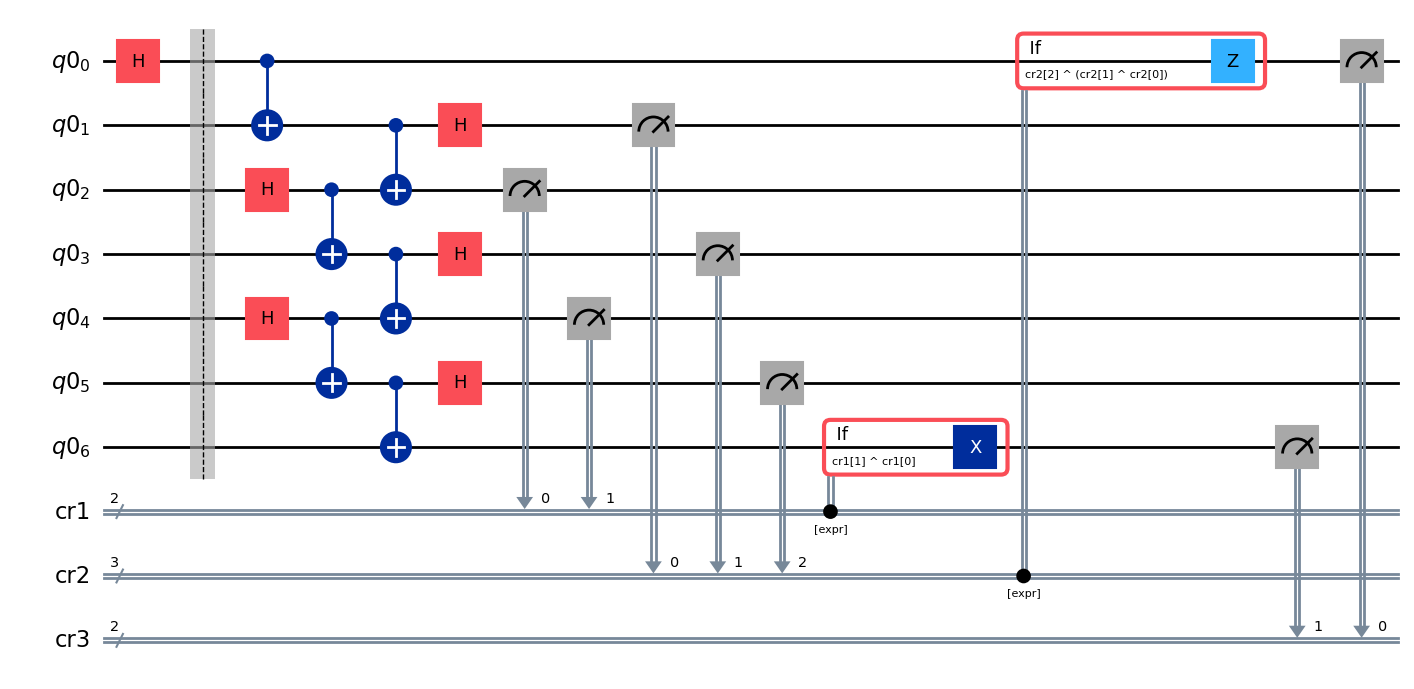

In [2]:
qc = get_dynamic_CNOT_circuit(num_qubit=7)
qc.draw(output="mpl")

In [5]:
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister

# 1. Let's create a couple of sample dynamic circuits to populate the batch
qc_list = []

# Circuit A: 3-qubit dynamic circuit
qr_a = QuantumRegister(3, name="q")
cr_a = ClassicalRegister(3, name="c")
qc_a = QuantumCircuit(qr_a, cr_a)
qc_a.h(qr_a[0])
qc_a.measure(qr_a[0], cr_a[0])
with qc_a.if_test((cr_a[0], 1)):
    qc_a.x(qr_a[1])
qc_a.measure(qr_a[1:], cr_a[1:])
qc_list.append(qc_a)

# Circuit B: Another dynamic step circuit for the batch
qr_b = QuantumRegister(3, name="q")
cr_b = ClassicalRegister(3, name="c")
qc_b = QuantumCircuit(qr_b, cr_b)
qc_b.h(qr_b[0])
qc_b.cx(qr_b[0], qr_b[1])
qc_b.measure(qr_b[1], cr_b[1])
with qc_b.if_test((cr_b[1], 1)):
    qc_b.x(qr_b[2])
qc_b.measure([qr_b[0], qr_b[2]], [cr_b[0], cr_b[2]])
qc_list.append(qc_b)

print(f"Created 'qc_list' containing {len(qc_list)} dynamic circuits.")

Created 'qc_list' containing 2 dynamic circuits.


In [11]:
from qiskit_aer import AerSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.circuit import Instruction

# 1. Initialize a 12-qubit simulated topology locally
total_physical_qubits = 12
fake_backend = GenericBackendV2(num_qubits=total_physical_qubits)
local_simulator = AerSimulator.from_backend(fake_backend)

# 2. Add control-flow footprints with an empty list for 'params' to satisfy __init__
local_simulator.target.add_instruction(
    Instruction(name="if_else", num_qubits=0, num_clbits=0, params=[]), name="if_else"
)
local_simulator.target.add_instruction(
    Instruction(name="while", num_qubits=0, num_clbits=0, params=[]), name="while"
)
local_simulator.target.add_instruction(
    Instruction(name="switch_case", num_qubits=0, num_clbits=0, params=[]),
    name="switch_case",
)
local_simulator.target.add_instruction(
    Instruction(name="for_in", num_qubits=0, num_clbits=0, params=[]), name="for_in"
)

print(
    f"Initialized local {total_physical_qubits}-qubit simulator target layout with custom control-flow signatures."
)

# 3. Setup the local compilation manager matching Qiskit standards
pm = generate_preset_pass_manager(optimization_level=1, backend=local_simulator)

# 4. Compile your batch of Trotter/Dynamic circuits completely offline
qc_transpiled_list = pm.run(qc_list)
print(
    f"Successfully transpiled {len(qc_transpiled_list)} circuits onto the 12-qubit local architecture."
)

Initialized local 12-qubit simulator target layout with custom control-flow signatures.
Successfully transpiled 2 circuits onto the 12-qubit local architecture.


In [12]:
from qiskit_aer.primitives import SamplerV2 as AerSampler

# 1. Initialize the local execution engine
sampler = AerSampler()

print("Submitting transpiled batch to local AerSimulator...")
# 2. Run the transpiled batch completely offline
job = sampler.run(qc_transpiled_list, shots=1024)
result = job.result()

print("\n--- Execution Results ---")
# 3. Parse and view the output metrics for each circuit in the batch
for i, pub_result in enumerate(result):
    # Dynamically extract classical register labels from the output data struct
    creg_keys = list(pub_result.data.keys())

    print(f"\nCircuit {i+1} Output:")
    for key in creg_keys:
        counts = pub_result.data[key].get_counts()
        print(f"  Register '{key}': {counts}")

Submitting transpiled batch to local AerSimulator...

--- Execution Results ---

Circuit 1 Output:
  Register 'c': {'011': 484, '000': 540}

Circuit 2 Output:
  Register 'c': {'111': 500, '000': 524}


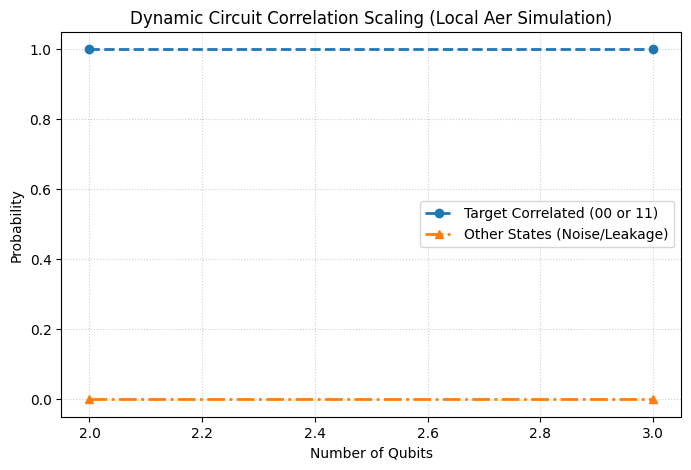

In [13]:
import matplotlib.pyplot as plt

# 1. Define the qubit scaling list for your batch (matching your 2 transpiled circuits)
# For example, if your circuits tested 2 qubits and 3 qubits respectively:
num_qubit_list = [2, 3]

list_Bell = []
list_other = []

# 2. Process the local result object obtained from AerSampler
for i in range(len(qc_transpiled_list)):
    pub_result = result[i]

    # Extract data using your local register key ('c')
    counts = pub_result.data.c.get_counts()
    total_counts = sum(counts.values())

    # Sum up combinations where the target bits show '00' or '11'
    # Slicing bitstrings[-2:] extracts the relevant correlated target pair
    bell_shots = 0
    for bitstring, count in counts.items():
        target_bits = bitstring[-2:]  # Check the last 2 classical bits
        if target_bits in ["00", "11"]:
            bell_shots += count

    prob_Bell = bell_shots / total_counts
    list_Bell.append(prob_Bell)
    list_other.append(1 - prob_Bell)

# 3. Generate the performance visualization chart locally
plt.figure(figsize=(8, 5))
plt.plot(
    num_qubit_list, list_Bell, "--o", label="Target Correlated (00 or 11)", linewidth=2
)
plt.plot(
    num_qubit_list, list_other, "-.^", label="Other States (Noise/Leakage)", linewidth=2
)

plt.xlabel("Number of Qubits")
plt.ylabel("Probability")
plt.title("Dynamic Circuit Correlation Scaling (Local Aer Simulation)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.show()